# Generating Handwritten Digits with a GAN

**Samuel Collins** - Ph.D. Student, Department of Cyber-Physical Systems,
Clark Atlanta University

Computer Vision, Lab Assignment 5. Instructor: Dr. Kishor Datta Gupta.

This notebook is a thin wrapper over the `gan_mnist` package in `src/`.
Every function it calls is the one `run_experiment.py` calls, so what runs
here is what produced the report - there is no second implementation to
drift.

The written analysis is in `report/GAN_MNIST_Report.pdf`. This notebook is
the executable evidence behind it.

## 1. Setup and configuration

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))

import torch
from IPython.display import Image, display

from gan_mnist import (
    RunConfig, data, evaluate, models, plots, resolve_device, summary, train,
)

config = RunConfig()
device = resolve_device()

print(f"torch          {torch.__version__}")
print(f"device         {device}")
print(f"seed           {config.seed}")
print(f"subset size    {config.subset_size:,}")
print(f"batch size     {config.batch_size}")
print(f"batches/epoch  {config.batches_per_epoch}")
print(f"epochs         {config.epochs}")
print(f"latent dim     {config.latent_dim}")
print(f"generator lr   {config.generator_lr:.0e}")
print(f"discrim. lr    {config.discriminator_lr:.0e}")
print(f"Adam betas     ({config.beta1}, {config.beta2})")
print(f"checkpoints    {config.checkpoints}")

torch          2.14.0
device         mps
seed           42
subset size    10,000
batch size     32
batches/epoch  312
epochs         5
latent dim     100
generator lr   2e-04
discrim. lr    2e-04
Adam betas     (0.5, 0.999)
checkpoints    (0, 1, 3, 5)


## 2. The data

A reproducible 10,000-image subset of the MNIST training split, normalized
to [-1, 1] to match the generator's `tanh` output. The indices and a
checksum over them are committed in `data/subset_manifest.json`; the images
are not, because the brief forbids submitting dataset downloads.

Digit labels are never an input - this is an unconditional GAN.

In [2]:
dataset, manifest = data.load_subset(config)

print(f"subset          {len(dataset):,} images")
print(f"checksum        {manifest['checksum'][:16]}")
print(f"image shape     {tuple(dataset[0][0].shape)}")
print(f"value range     [{dataset[0][0].min():.2f}, {dataset[0][0].max():.2f}]")
print(f"normalization   {manifest['normalization']}")

subset          10,000 images
checksum        0a1b4f46cd55d4f9
image shape     (1, 28, 28)
value range     [-1.00, 1.00]
normalization   ToTensor to [0, 1], then (x - 0.5) / 0.5 to [-1, 1]


### Sixteen real examples

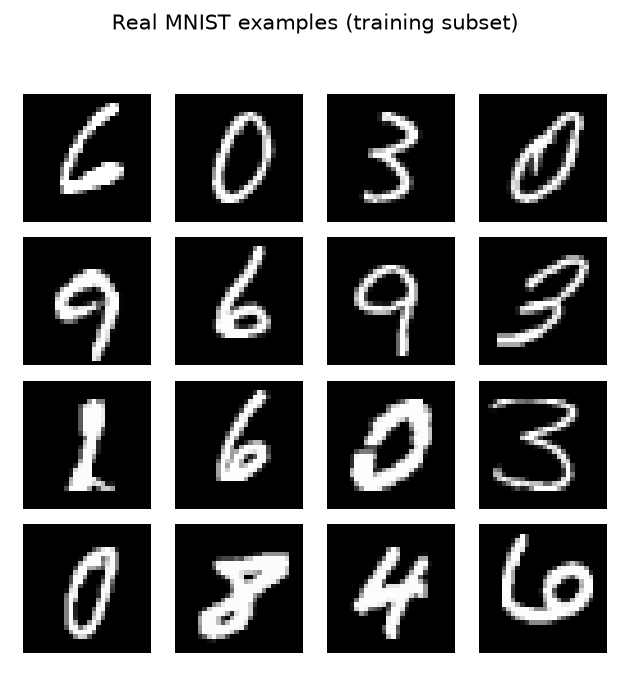

In [3]:
path = plots.save_real_grid(dataset, Path("plots/real_samples.png"),
                            seed=config.seed)
display(Image(filename=path))

## 3. The two networks

The generator maps noise to an image; the discriminator scores an image as
real or generated. Shapes below are measured by running a batch through
with forward hooks, not derived from the constructor arguments.

In [4]:
architecture = summary.both(config)

for which in ("generator", "discriminator"):
    block = architecture[which]
    counts = block["parameters"]
    print(f"\n{block['name']}  -  input {tuple(block['input_shape'])}  -  "
          f"{counts['total']:,} parameters, all trainable")
    print(f"{'layer':<10} {'type':<14} {'output shape':<18} {'params':>10}")
    print("-" * 56)
    for row in block["layers"]:
        print(f"{row['layer']:<10} {row['type']:<14} "
              f"{str(tuple(row['output_shape'])):<18} {row['parameters']:>10,}")


Generator  -  input (100,)  -  1,489,424 parameters, all trainable
layer      type           output shape           params
--------------------------------------------------------
net.0      Linear         (256,)                 25,856
net.1      LeakyReLU      (256,)                      0
net.2      Linear         (512,)                131,584
net.3      BatchNorm1d    (512,)                  1,024
net.4      LeakyReLU      (512,)                      0
net.5      Linear         (1024,)               525,312
net.6      BatchNorm1d    (1024,)                 2,048
net.7      LeakyReLU      (1024,)                     0
net.8      Linear         (784,)                803,600
net.9      Tanh           (784,)                      0

Discriminator  -  input (1, 28, 28)  -  533,505 parameters, all trainable
layer      type           output shape           params
--------------------------------------------------------
net.0      Flatten        (784,)                      0
net.1      Line

### What each network is for, and why the objectives differ

**The generator's input** is a 100-dimensional vector of independent
standard normals and nothing else. It carries no information about digits.
Everything the samples eventually show is stored in the generator's weights.
The output is bounded to [-1, 1] by `tanh`, matching the data's range.

**The discriminator's target** is a single real-or-generated decision, not
a digit class. Its labels come free with the data: MNIST images are real,
anything the generator just made is not.

**The objectives differ because both networks want opposite things from the
same number.** The discriminator wants its score high on real images and
low on generated ones; the generator wants that same score high on its own
output. Neither has a loss it can minimize alone, and the discriminator's
task gets harder exactly as the generator improves. This is why neither
loss can be read the way a classifier's training loss is read.

**The discriminator returns a logit**, not a probability - there is no
sigmoid on the output - and the loss is `BCEWithLogitsLoss`, which applies
the sigmoid inside the loss in log space. That pairing is what the brief
asks be kept consistent.

In [5]:
_, discriminator = models.build(config)
discriminator.eval()
with torch.no_grad():
    extreme = discriminator(torch.randn(256, 1, 28, 28) * 50)

print(f"final layer            {discriminator.net[-1]}")
print(f"output range           [{extreme.min():.2f}, {extreme.max():.2f}]")
print("a probability could not leave [0, 1]; this is a logit")

final layer            Linear(in_features=256, out_features=1, bias=True)
output range           [-7.77, 14.04]
a probability could not leave [0, 1]; this is a logit


## 4. The alternating updates

Each batch is one discriminator step then one generator step.

**Discriminator step** - updates the discriminator only. The generated
batch is passed as `fake.detach()`, which severs the graph so no gradient
reaches the generator, and the optimizer holds discriminator parameters
only.

**Generator step** - updates the generator only. The *non-detached* `fake`
is scored, so backward runs through the discriminator into the generator:
that path is what lets the generator learn from how it was scored. The
discriminator accumulates gradients on the way through and they are never
applied.

The cell below demonstrates both on real parameters rather than describing
them. `tests/test_train.py` asserts the same things.

In [6]:
from torch import nn

generator, discriminator = models.build(config)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=config.generator_lr)
optimizer_d = torch.optim.Adam(discriminator.parameters(),
                               lr=config.discriminator_lr)
criterion = nn.BCEWithLogitsLoss()

real = torch.stack([dataset[i][0] for i in range(config.batch_size)])
noise = torch.randn(config.batch_size, config.latent_dim)

def snapshot(module):
    return {n: p.detach().clone() for n, p in module.named_parameters()}

def moved(module, before):
    return sum(1 for n, p in module.named_parameters()
               if not torch.equal(p.detach(), before[n]))

g_before, d_before = snapshot(generator), snapshot(discriminator)
_, fake = train.discriminator_step(generator, discriminator, optimizer_d,
                                   criterion, real, noise)
print("after the DISCRIMINATOR step")
print(f"  generator tensors changed:     {moved(generator, g_before)}")
print(f"  discriminator tensors changed: {moved(discriminator, d_before)}")

g_before, d_before = snapshot(generator), snapshot(discriminator)
generator.zero_grad(set_to_none=True)
train.generator_step(generator, discriminator, optimizer_g, criterion, fake)
print("\nafter the GENERATOR step")
print(f"  generator tensors changed:     {moved(generator, g_before)}")
print(f"  discriminator tensors changed: {moved(discriminator, d_before)}")
print(f"  generator tensors with gradient: "
      f"{sum(1 for p in generator.parameters() if p.grad is not None)}"
      f"  (the path through the discriminator was preserved)")

after the DISCRIMINATOR step
  generator tensors changed:     0
  discriminator tensors changed: 6

after the GENERATOR step
  generator tensors changed:     12
  discriminator tensors changed: 0
  generator tensors with gradient: 12  (the path through the discriminator was preserved)


## 5. Baseline run

Five epochs. The same sixteen noise vectors are rendered before training
and after epochs 1, 3 and 5, so what changes between grids is the
generator and nothing else.

In [7]:
def run(config):
    loader = data.make_loader(dataset, config)
    fixed_noise = evaluate.make_fixed_noise(config)
    grids = {}

    def on_checkpoint(epoch, images):
        path = Path("plots") / f"{config.name}_grid_epoch{epoch}.png"
        plots.save_grid(images, path,
                        plots.checkpoint_title(config.name, epoch))
        grids[epoch] = str(path)
        return {"grid": str(path)}

    result = train.train(config, loader, device, fixed_noise,
                         on_checkpoint=on_checkpoint)
    result["grids"] = grids
    return result

baseline = run(config)
print(f"\ntotal {baseline['total_seconds']:.1f}s on {baseline['device']}")
print(f"fixed noise checksum {baseline['fixed_noise_checksum'][:16]}")

  epoch 1/5  G 0.8617  D 1.2925  D-acc 0.594  1.2s


  epoch 2/5  G 0.8835  D 1.2566  D-acc 0.644  1.1s


  epoch 3/5  G 0.8858  D 1.2666  D-acc 0.639  1.2s


  epoch 4/5  G 0.8890  D 1.2738  D-acc 0.635  1.1s


  epoch 5/5  G 0.9104  D 1.2707  D-acc 0.636  1.1s

total 6.0s on mps
fixed noise checksum dcf03d6f6db5e7b2


### Checkpoint grids - the same sixteen vectors throughout

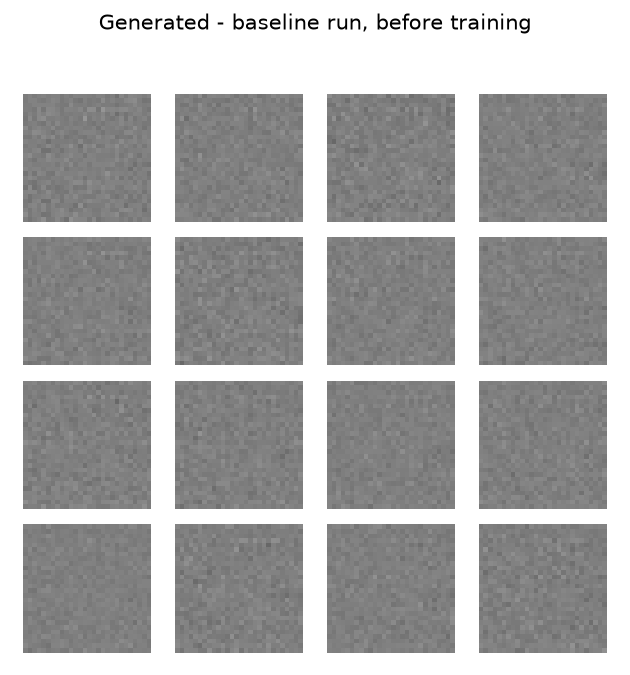

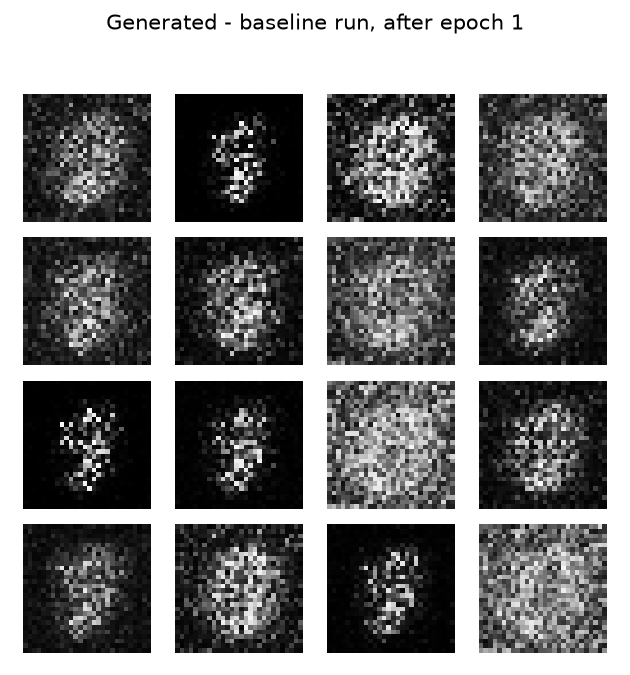

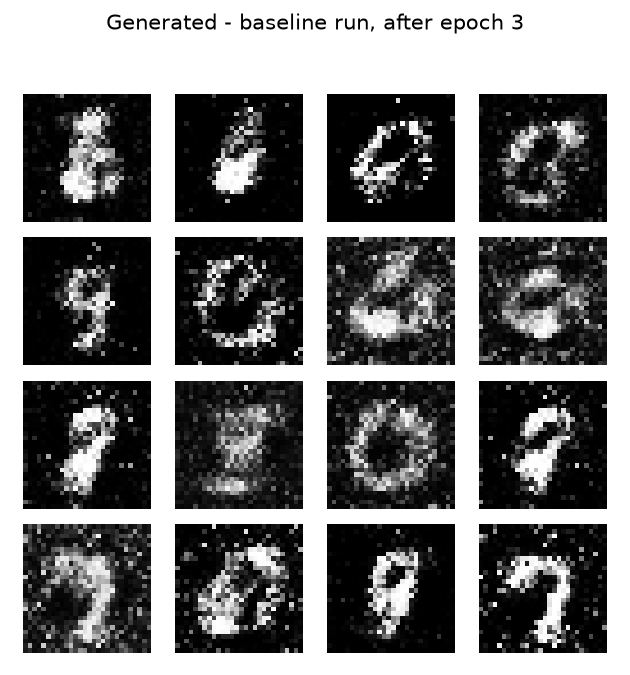

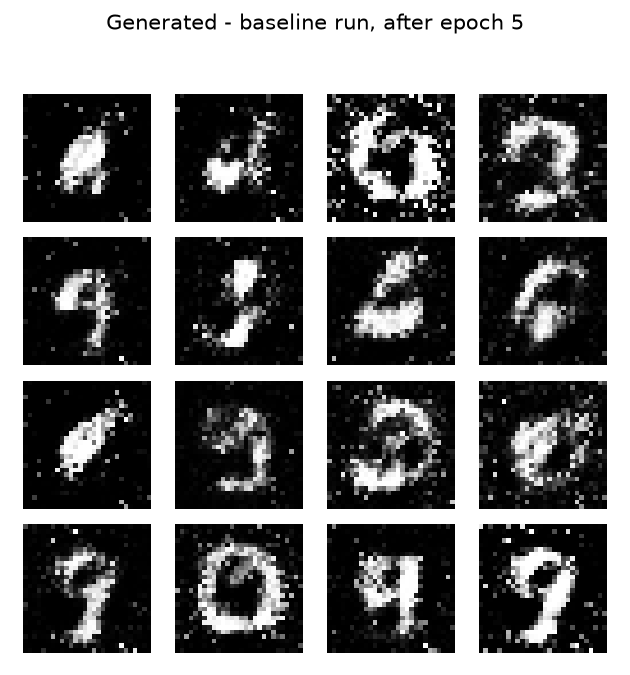

In [8]:
for epoch in config.checkpoints:
    display(Image(filename=baseline["grids"][epoch]))

### Loss curves

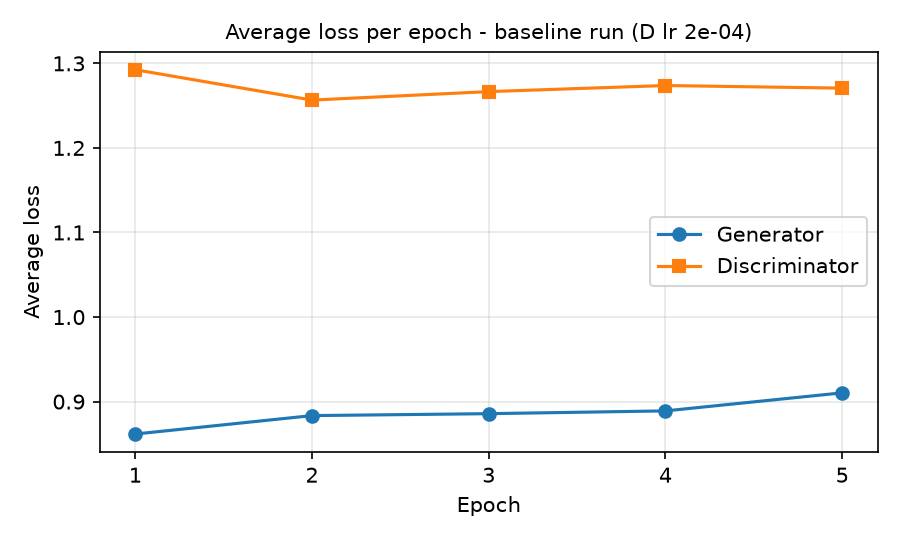

In [9]:
path = plots.save_loss_curves(
    baseline["history"], Path("plots/baseline_losses.png"),
    f"Average loss per epoch - {config.name} run "
    f"(D lr {config.discriminator_lr:.0e})")
display(Image(filename=path))

## 6. The controlled comparison

The same experiment from scratch with the discriminator learning rate
lowered from 2e-4 to 2e-5. The generator learning rate, architecture, data
subset, batch size, epoch budget, seed and fixed evaluation noise are
unchanged - `RunConfig.contrast()` changes one field, so a second
difference cannot be introduced by editing the wrong line, and
`scripts/validate_results.py` fails the build if one is.

In [10]:
contrast_config = config.contrast(2e-5)

differs = [k for k, v in config.to_dict().items()
           if contrast_config.to_dict()[k] != v]
print(f"fields that differ between the runs: {differs}")

contrast = run(contrast_config)
print(f"\ntotal {contrast['total_seconds']:.1f}s")
print(f"same evaluation noise: "
      f"{contrast['fixed_noise_checksum'] == baseline['fixed_noise_checksum']}")

fields that differ between the runs: ['name', 'discriminator_lr']


  epoch 1/5  G 0.5375  D 1.4307  D-acc 0.493  1.1s


  epoch 2/5  G 0.6233  D 1.4061  D-acc 0.472  1.1s


  epoch 3/5  G 0.6407  D 1.4054  D-acc 0.463  1.1s


  epoch 4/5  G 0.6573  D 1.3998  D-acc 0.464  1.1s


  epoch 5/5  G 0.6365  D 1.3995  D-acc 0.483  1.1s

total 5.7s
same evaluation noise: True


### Both final grids, side by side in reading order

discriminator lr 2e-04  -  final generator loss 0.9104  -  discriminator accuracy 0.636


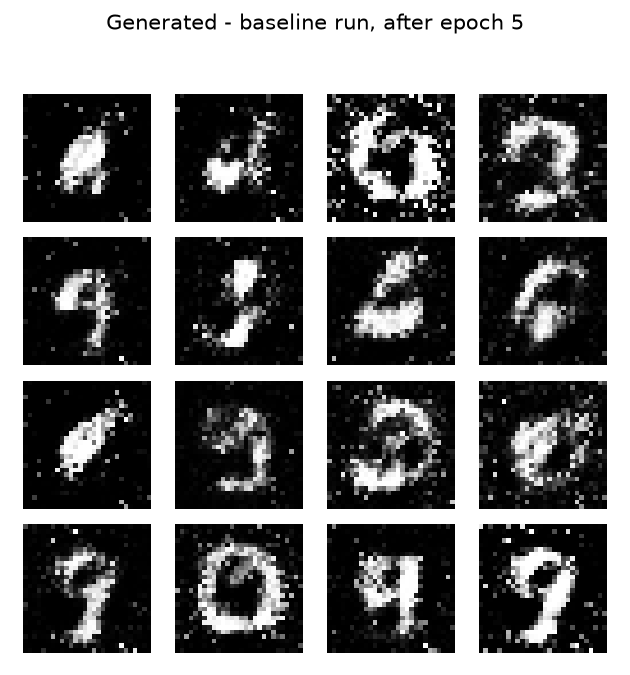

discriminator lr 2e-05  -  final generator loss 0.6365  -  discriminator accuracy 0.483


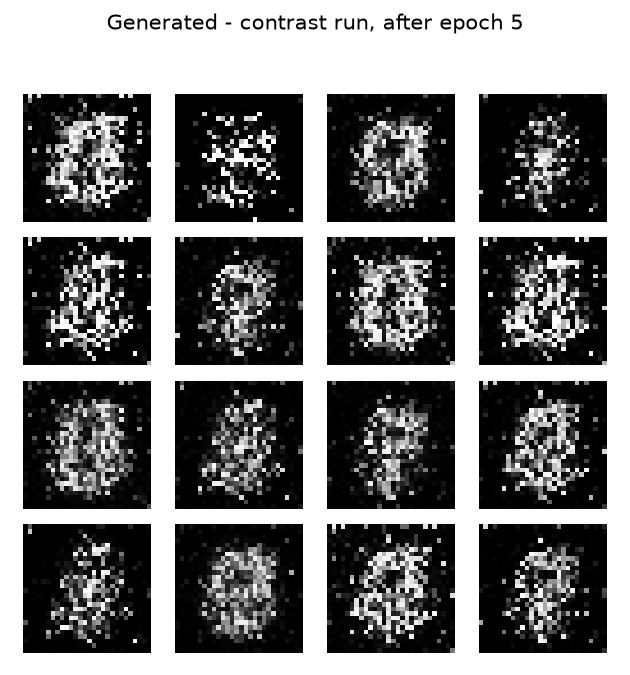

In [11]:
for result in (baseline, contrast):
    lr = result["config"]["discriminator_lr"]
    print(f"discriminator lr {lr:.0e}  -  final generator loss "
          f"{result['history'][-1]['generator_loss']:.4f}  -  "
          f"discriminator accuracy "
          f"{result['history'][-1]['discriminator_accuracy']:.3f}")
    display(Image(filename=result["grids"][config.epochs]))

### Loss and accuracy, both runs

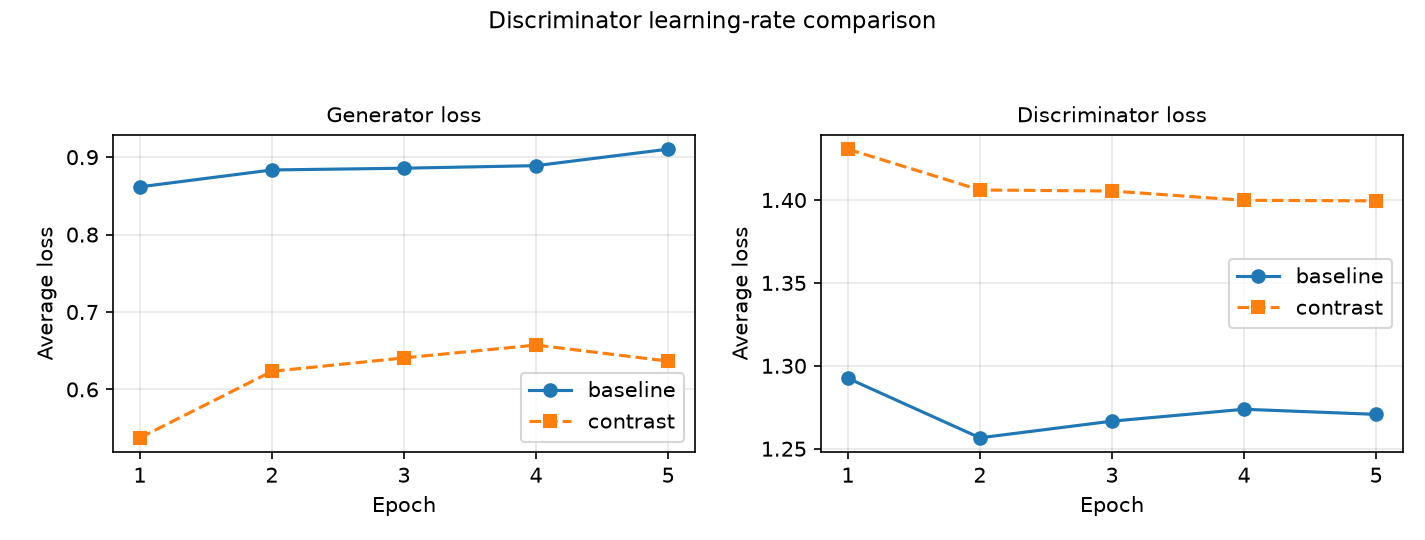

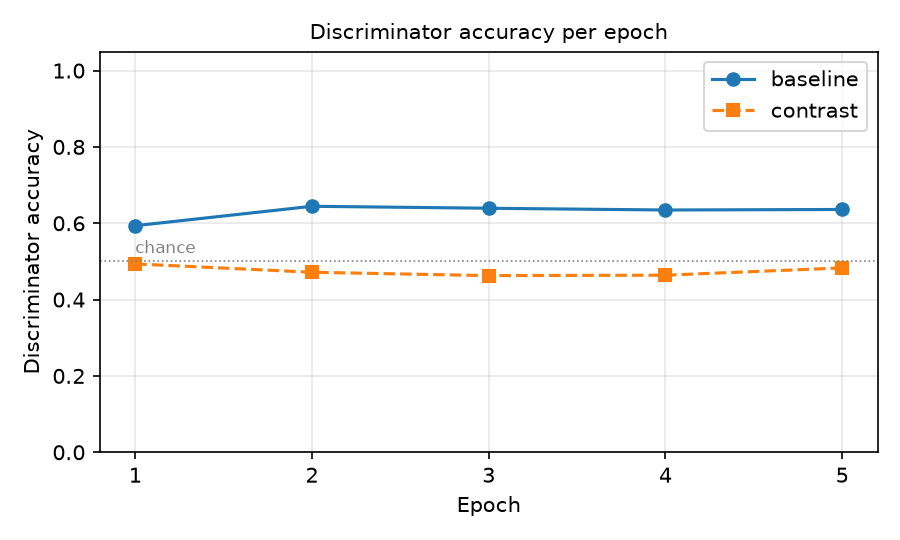

In [12]:
histories = {"baseline": baseline["history"], "contrast": contrast["history"]}

display(Image(filename=plots.save_comparison_curves(
    histories, Path("plots/comparison_losses.png"),
    "Discriminator learning-rate comparison")))
display(Image(filename=plots.save_accuracy_curves(
    histories, Path("plots/comparison_accuracy.png"),
    "Discriminator accuracy per epoch")))

### Settings and runtime

In [13]:
rows = [
    ("Discriminator learning rate", lambda r: f"{r['config']['discriminator_lr']:.0e}"),
    ("Generator learning rate", lambda r: f"{r['config']['generator_lr']:.0e}"),
    ("Random seed", lambda r: str(r["config"]["seed"])),
    ("Training images", lambda r: f"{r['config']['subset_size']:,}"),
    ("Batch size", lambda r: str(r["config"]["batch_size"])),
    ("Epochs", lambda r: str(r["config"]["epochs"])),
    ("Latent dimension", lambda r: str(r["config"]["latent_dim"])),
    ("Device", lambda r: r["device"]),
    ("Runtime", lambda r: f"{r['total_seconds']:.1f} s"),
    ("Final generator loss", lambda r: f"{r['history'][-1]['generator_loss']:.4f}"),
    ("Final discriminator loss", lambda r: f"{r['history'][-1]['discriminator_loss']:.4f}"),
    ("Final discriminator accuracy", lambda r: f"{r['history'][-1]['discriminator_accuracy']:.3f}"),
]
print(f"{'setting':<30} {'baseline':>14} {'contrast':>14}")
print("-" * 60)
for label, accessor in rows:
    print(f"{label:<30} {accessor(baseline):>14} {accessor(contrast):>14}")

setting                              baseline       contrast
------------------------------------------------------------
Discriminator learning rate             2e-04          2e-05
Generator learning rate                 2e-04          2e-04
Random seed                                42             42
Training images                        10,000         10,000
Batch size                                 32             32
Epochs                                      5              5
Latent dimension                          100            100
Device                                    mps            mps
Runtime                                 6.0 s          5.7 s
Final generator loss                   0.9104         0.6365
Final discriminator loss               1.2707         1.3995
Final discriminator accuracy            0.636          0.483


## 7. What this shows

The contrast run ends with the **lower** generator loss and the **worse**
images. Its discriminator never became a useful critic - accuracy near
chance and a loss close to the 1.386 that two chance-level cross-entropy
terms produce - so the generator optimized against an uninformative signal.
A low generator loss against a weak discriminator says the discriminator is
weak, not that the generator is good.

The full 400-600 word analysis, the four-rate supplementary sweep, the
three-seed replication and the limitations are in
`report/GAN_MNIST_Report.pdf`.

Reproduce everything with:

```
.venv/bin/python scripts/run_all.py
```